In [ ]:
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split #split arrays or matrices into random train and test subsets
import sys # for manipulating the Python runtime environment
import os # for interacting with the operating system
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Get the current working directory (where the notebook is located)
current_dir = os.getcwd() # Get the current directory

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
# Ensure the parent directory is in sys.path so we can import modules from it
# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)
from field import Field



from data_creator import load_2D
df = load_2D().dropna() # load data from files

In [ ]:
df.isna().sum()
df.shape
df.info()
df.describe()


In [ ]:


def summarize_ad_by_date(df, date_str):
    """
    date_str: should be in the same format as in your data (e.g., "12/08/2023")
    """
    subset = df[df["QADate"] == date_str]

    if subset.empty:
        print(f"No data found for date {date_str}")
        return

    ad_stats = subset["AD"].describe()
    iqr = subset["AD"].quantile(0.75) - subset["AD"].quantile(0.25)
    variance = subset["AD"].var()

    print(f"\n--- Summary Stats for {date_str} ({len(subset)} fields) ---")
    print(ad_stats)
    print(f"IQR: {iqr:.2f}")
    print(f"Variance: {variance:.2f}")
    print("----------------------------------------------------\n")


In [ ]:
def print_field_counts_by_date(df):
    """
    Print the number of fields for each QADate in the dataset.
    """
    field_counts = df.groupby("QADate").size().sort_index()
    print("\n--- Field Counts by QA Date ---")
    for date, count in field_counts.items():
        print(f"{date}: {count} fields")
    print(f"\nTotal fields: {field_counts.sum()}")
    print("----------------------------------\n")


In [ ]:


def plot_ad_summary_by_date(df):
    # Convert date to datetime
    df["QADate"] = pd.to_datetime(df["QADate"], format="%m/%d/%Y")

    # Group by date and summarize
    summary_df = df.groupby("QADate")["AD"].agg(["mean", "std", "min", "max"]).reset_index()
    summary_df["QADate_mpl"] = mdates.date2num(summary_df["QADate"])  # for fill_between

    # Extract arrays for plotting
    x = np.array(summary_df["QADate_mpl"], dtype="float64")
    ymin = np.array(summary_df["min"], dtype="float64")
    ymax = np.array(summary_df["max"], dtype="float64")

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(summary_df["QADate"], summary_df["mean"], marker="o", label="Mean AD")
    ax.fill_between(x, ymin, ymax, alpha=0.3, label="Min–Max Range")
    ax.errorbar(summary_df["QADate"], summary_df["mean"], yerr=summary_df["std"],
                fmt='none', ecolor='gray', capsize=4)

    # Format
    ax.set_title("ArcCHECK AD Gamma Pass Rate – Summary per QA Date")
    ax.set_ylabel("AD (%)")
    ax.set_xlabel("QA Date")
    ax.legend()
    ax.grid(True)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %Y'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_ad_boxplot_by_date(df):
    # Ensure proper datetime format
    df["QADate"] = pd.to_datetime(df["QADate"], format="%m/%d/%Y")

    # Sort dates for cleaner plot
    df = df.sort_values("QADate")
    
    # Plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="QADate", y="AD", palette="pastel")
    
    
    

    # Format
    plt.title("ArcCHECK AD Gamma Pass Rate – Boxplot by QA Date")
    plt.ylabel("AD (%)")
    plt.xlabel("QA Date")
    plt.xticks(rotation=45)
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_ad_summary_plots_for_date(df, date_str):
    """
    Creates 3 summary plots (boxplot, histogram, violin) for a specific QA date.
    date_str: "MM/DD/YYYY"
    """
    # Convert date
    df["QADate"] = pd.to_datetime(df["QADate"], format="%m/%d/%Y")
    target_date = pd.to_datetime(date_str, format="%m/%d/%Y")

    # Filter data
    subset = df[df["QADate"] == target_date]

    if subset.empty:
        print(f"No data found for date {date_str}")
        return

    # Set up subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Boxplot
    sns.boxplot(data=subset, y="AD", ax=axes[0], color="skyblue")
    axes[0].set_title(f"Boxplot of AD – {date_str}")
    axes[0].set_ylabel("AD (%)")

    # Histogram
    sns.histplot(subset["AD"], kde=True, ax=axes[1], color="mediumseagreen")
    axes[1].set_title(f"Histogram of AD – {date_str}")
    axes[1].set_xlabel("AD (%)")
    axes[1].set_ylabel("Count")

    # Violin plot
    sns.stripplot(data=subset, y="AD", ax=axes[2], color="orangered", size=6, jitter=True)
    axes[2].set_title(f"Strip Plot of AD – {date_str}")


    # Final formatting
    plt.tight_layout()
    plt.show()


In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_ad_summary_stats_with_passrate(df, date_str):
    """
    Plots Boxplot, Histogram, and Summary Statistics + Pass Rate for AD on a specific date.
    """
    # Convert date
    df["QADate"] = pd.to_datetime(df["QADate"], format="%m/%d/%Y")
    target_date = pd.to_datetime(date_str, format="%m/%d/%Y")
    subset = df[df["QADate"] == target_date]

    if subset.empty:
        print(f"No data found for date {date_str}")
        return

    # Summary stats
    ad_stats = subset["AD"].describe()
    iqr = ad_stats["75%"] - ad_stats["25%"]
    variance = subset["AD"].var()

    # Calculate AD ≥ ADPass
    if "ADPass" in subset.columns:
        pass_count = (subset["AD"] >= subset["ADPass"]).sum()
        total_count = len(subset)
        pass_rate = (pass_count / total_count) * 100
    else:
        pass_count = total_count = pass_rate = "N/A"

    # Plot setup
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Boxplot
    sns.boxplot(data=subset, y="AD", ax=axes[0], color="skyblue")
    axes[0].set_title(f"Boxplot of AD – {date_str}")
    axes[0].set_ylabel("AD (%)")

    # Histogram
    sns.histplot(subset["AD"], kde=True, ax=axes[1], color="mediumseagreen")
    axes[1].set_title(f"Histogram of AD – {date_str}")
    axes[1].set_xlabel("AD (%)")
    axes[1].set_ylabel("Count")

    # Summary stats panel
    stats_text = (
        f"n = {int(ad_stats['count'])}\n"
        f"Mean = {ad_stats['mean']:.2f}\n"
        f"Median = {ad_stats['50%']:.2f}\n"
        f"Std Dev = {ad_stats['std']:.2f}\n"
        f"IQR = {iqr:.2f}\n"
        f"Min = {ad_stats['min']:.2f}\n"
        f"Max = {ad_stats['max']:.2f}\n"
        f"Variance = {variance:.2f}\n"
        f"Pass Rate (AD ≥ ADPass) = {pass_rate:.2f}%"
    )

    axes[2].axis("off")
    axes[2].text(0.01, 0.95, stats_text, fontsize=12, va="top", ha="left", family="monospace")
    axes[2].set_title("AD Summary & Pass Rate", fontsize=14)

    # Final layout
    plt.tight_layout()
    plt.show()



--- Summary Stats for 12/11/2023 (32 fields) ---
count    32.000000
mean     90.728125
std       5.884766
min      77.800000
25%      86.575000
50%      91.350000
75%      94.650000
max      99.700000
Name: AD, dtype: float64
IQR: 8.07
Variance: 34.63
----------------------------------------------------



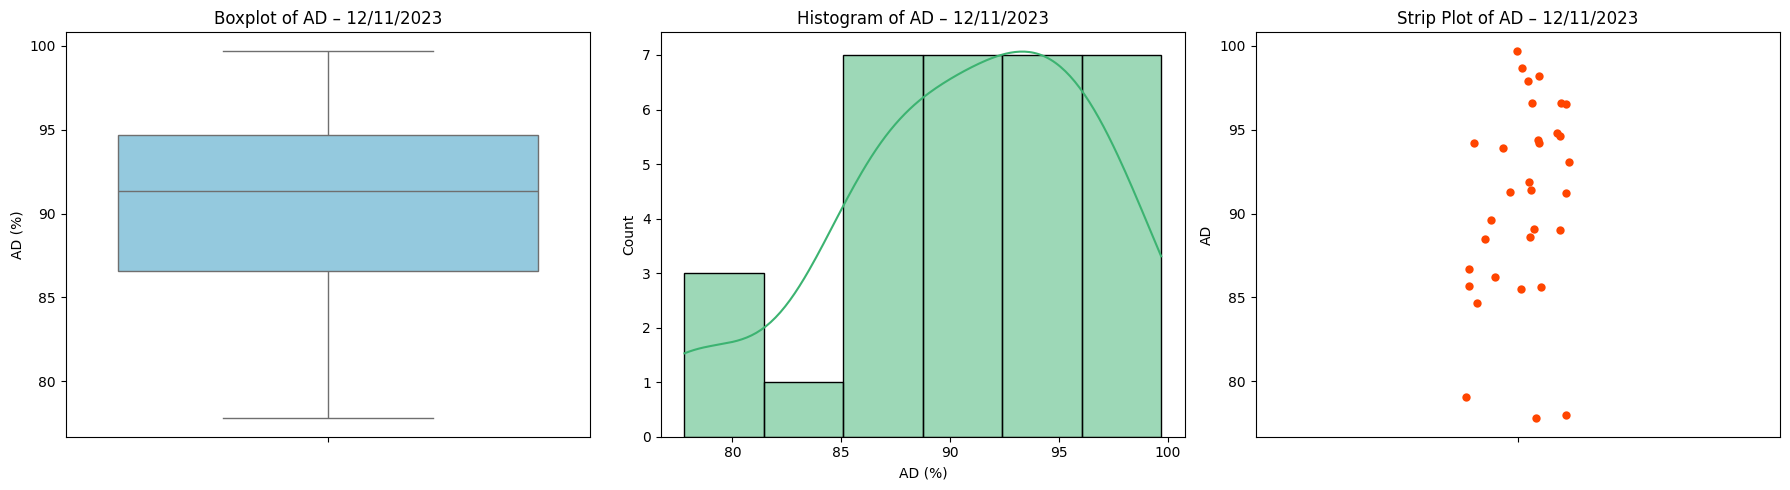

In [ ]:
summarize_ad_by_date(df,"12/11/2023")


In [53]:
print_field_counts_by_date(df)


--- Field Counts by QA Date ---
2023-11-06 00:00:00: 38 fields
2023-12-08 00:00:00: 37 fields
2023-12-11 00:00:00: 32 fields
2023-12-12 00:00:00: 42 fields
2023-12-13 00:00:00: 25 fields
2023-12-14 00:00:00: 20 fields
2023-12-15 00:00:00: 31 fields
2023-12-18 00:00:00: 20 fields
2023-12-19 00:00:00: 22 fields
2023-12-20 00:00:00: 35 fields
2023-12-21 00:00:00: 25 fields

Total fields: 327
----------------------------------



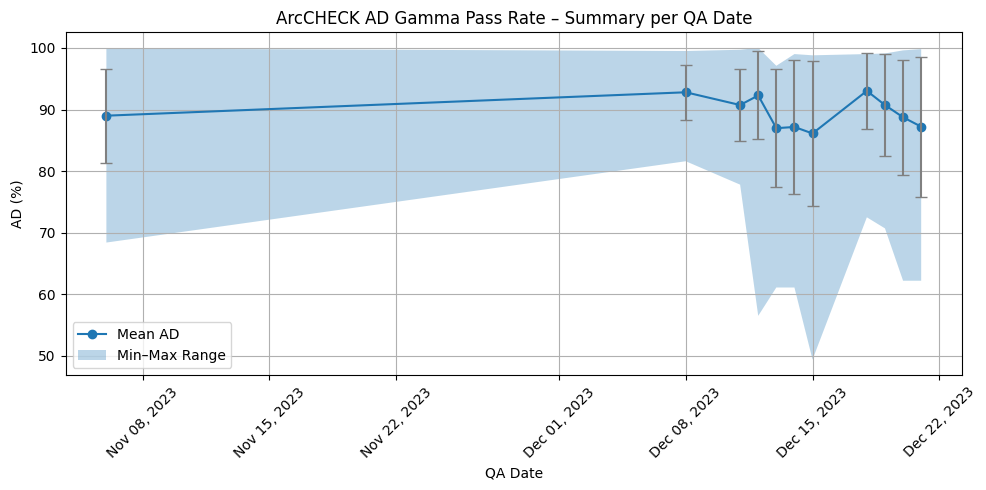

In [55]:
plot_ad_summary_by_date(df)

/var/folders/t7/mb1zb_5n6656xzdnkv80lmkr0000gn/T/ipykernel_57866/172245513.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="QADate", y="AD", palette="pastel")


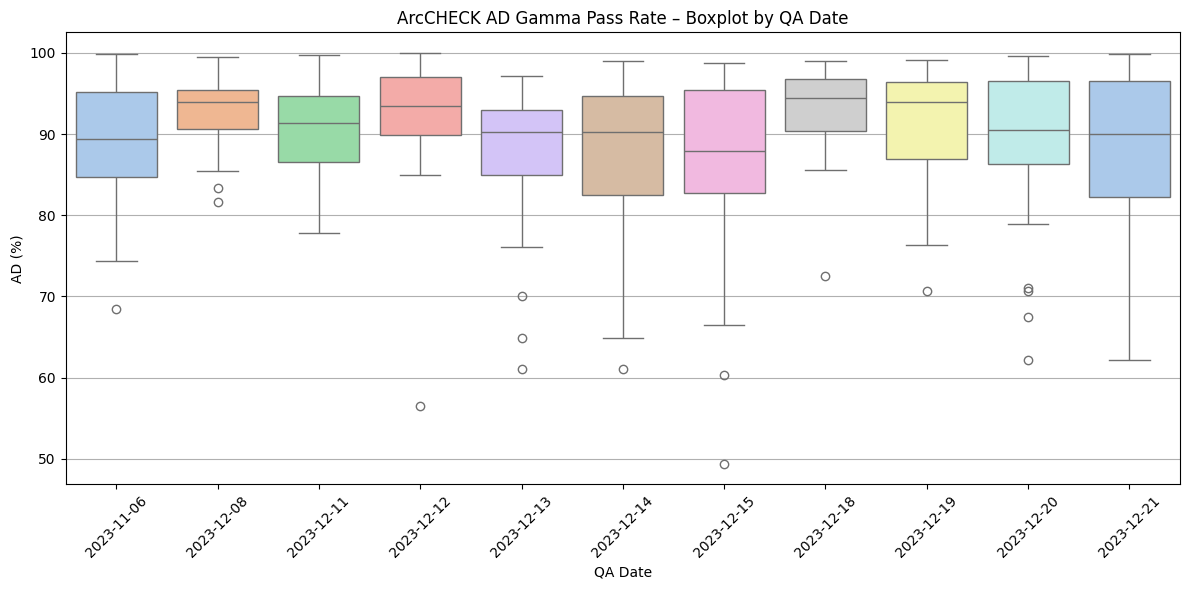

In [58]:

plot_ad_boxplot_by_date(df)


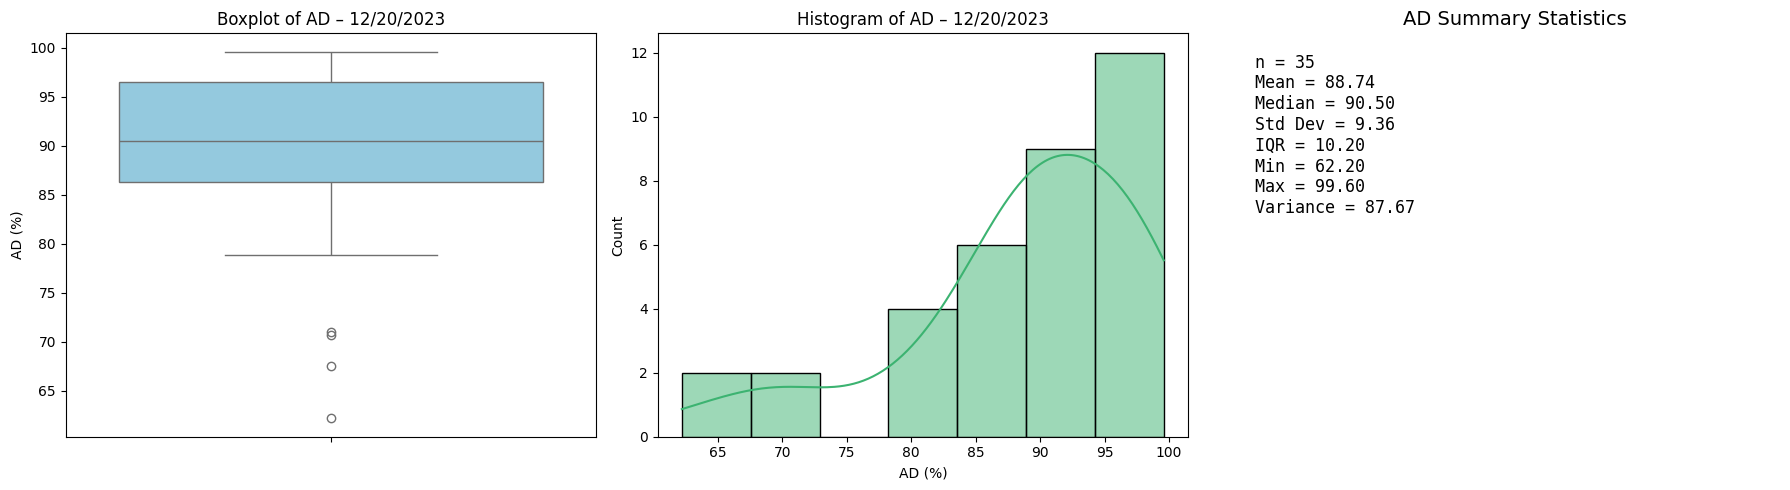

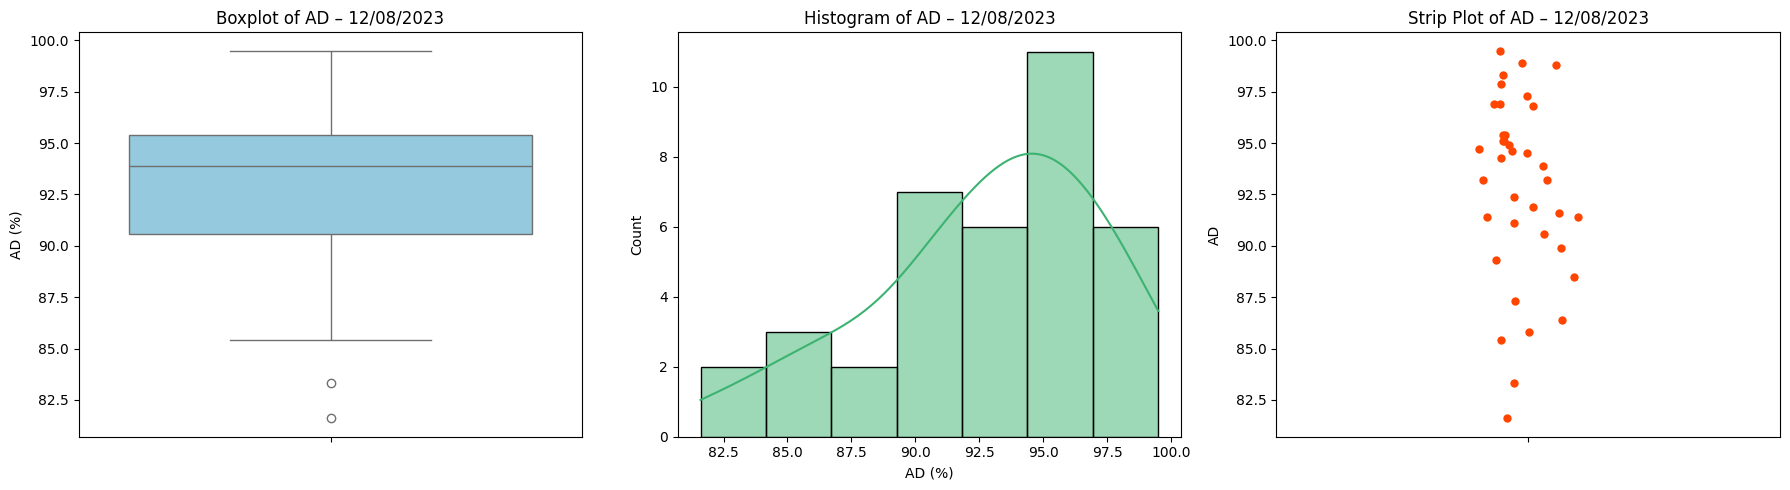

In [75]:
plot_ad_summary_plots_for_date(df, "12/08/2023")

AD Summary:
count    327.000000
mean      89.675841
std        8.717390
min       49.400000
25%       86.250000
50%       91.600000
75%       95.850000
max      100.000000
Name: AD, dtype: float64


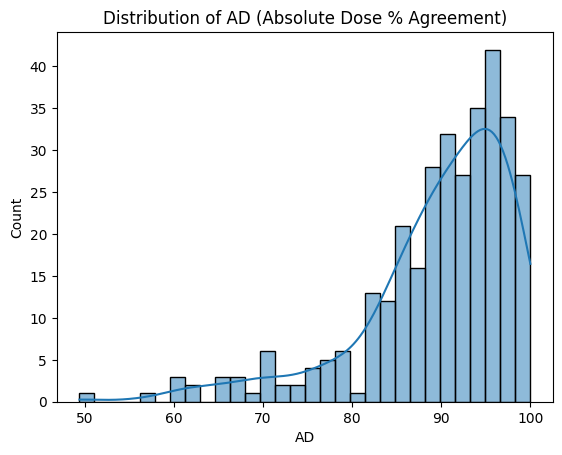

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Summary stats
print("AD Summary:")
print(df["AD"].describe())

# Histogram
sns.histplot(df["AD"], kde=True, bins=30)
plt.title("Distribution of AD (Absolute Dose % Agreement)")
plt.xlabel("AD")
plt.ylabel("Count")
plt.show()


<Axes: >

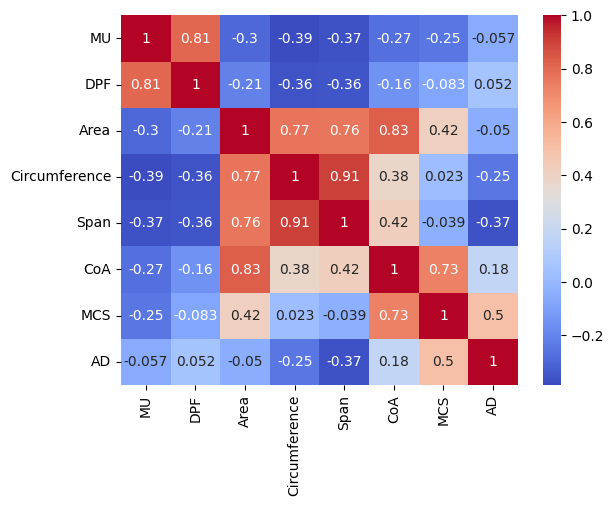

In [80]:

num_cols = ["MU", "DPF", "Area", "Circumference", "Span", "CoA", "MCS"]
import matplotlib.pyplot as plt
corr = df[num_cols + ["AD"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")



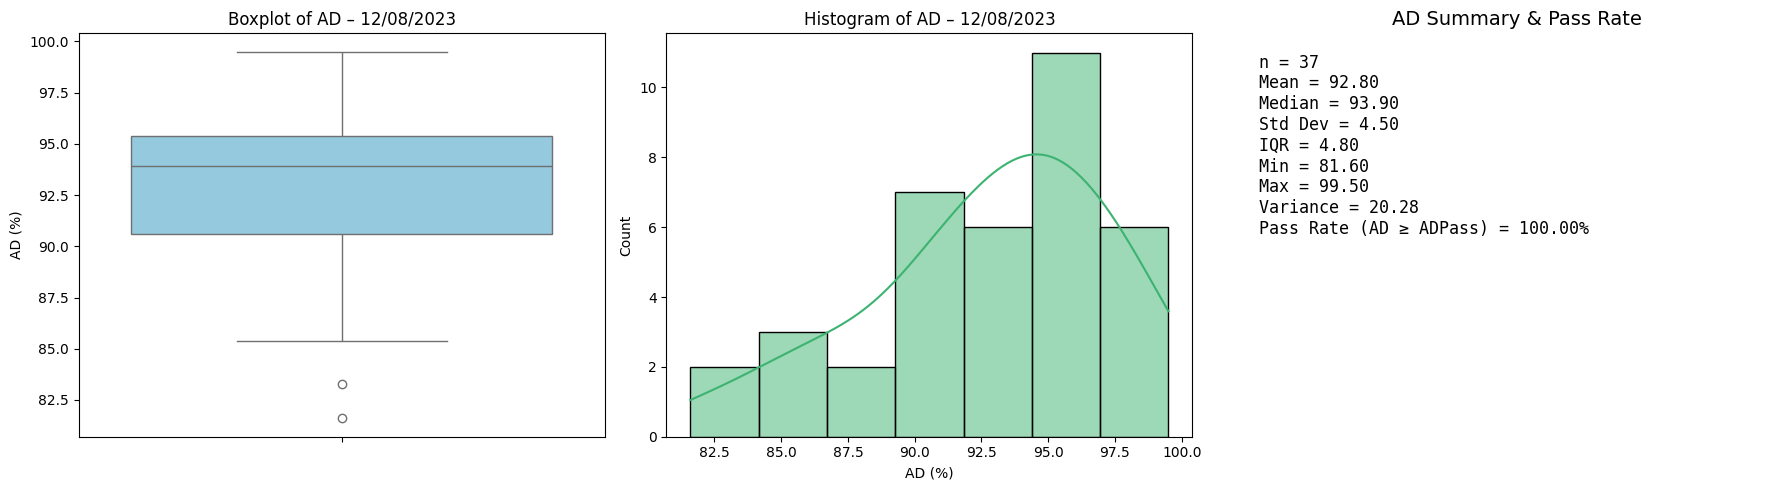

In [82]:
plot_ad_summary_stats_with_passrate(df, "12/08/2023")
